In [1]:
!pip install mne

In [3]:
!pip install -q mne

EEG PREPROCESSING STARTED

ORIGINAL EEG
Number of channels: 64
Sampling frequency: 160.0 Hz
Duration: 60.99375 seconds

STEP 2 - AVERAGE REFERENCE


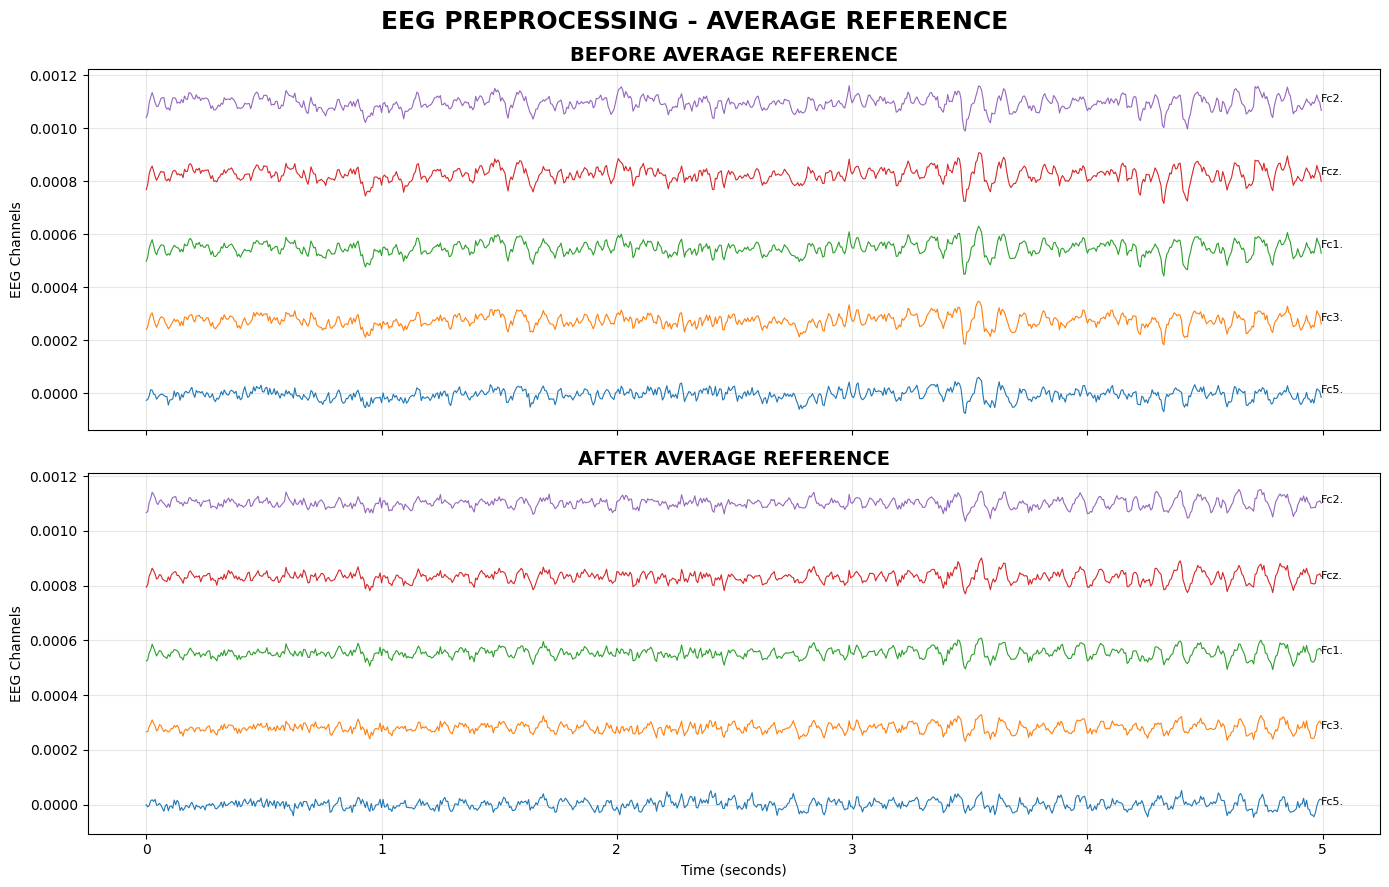

Saved: /content/eeg_graphs/01_average_reference.png

STEP 3 - BAND-PASS FILTER (1-45 Hz)


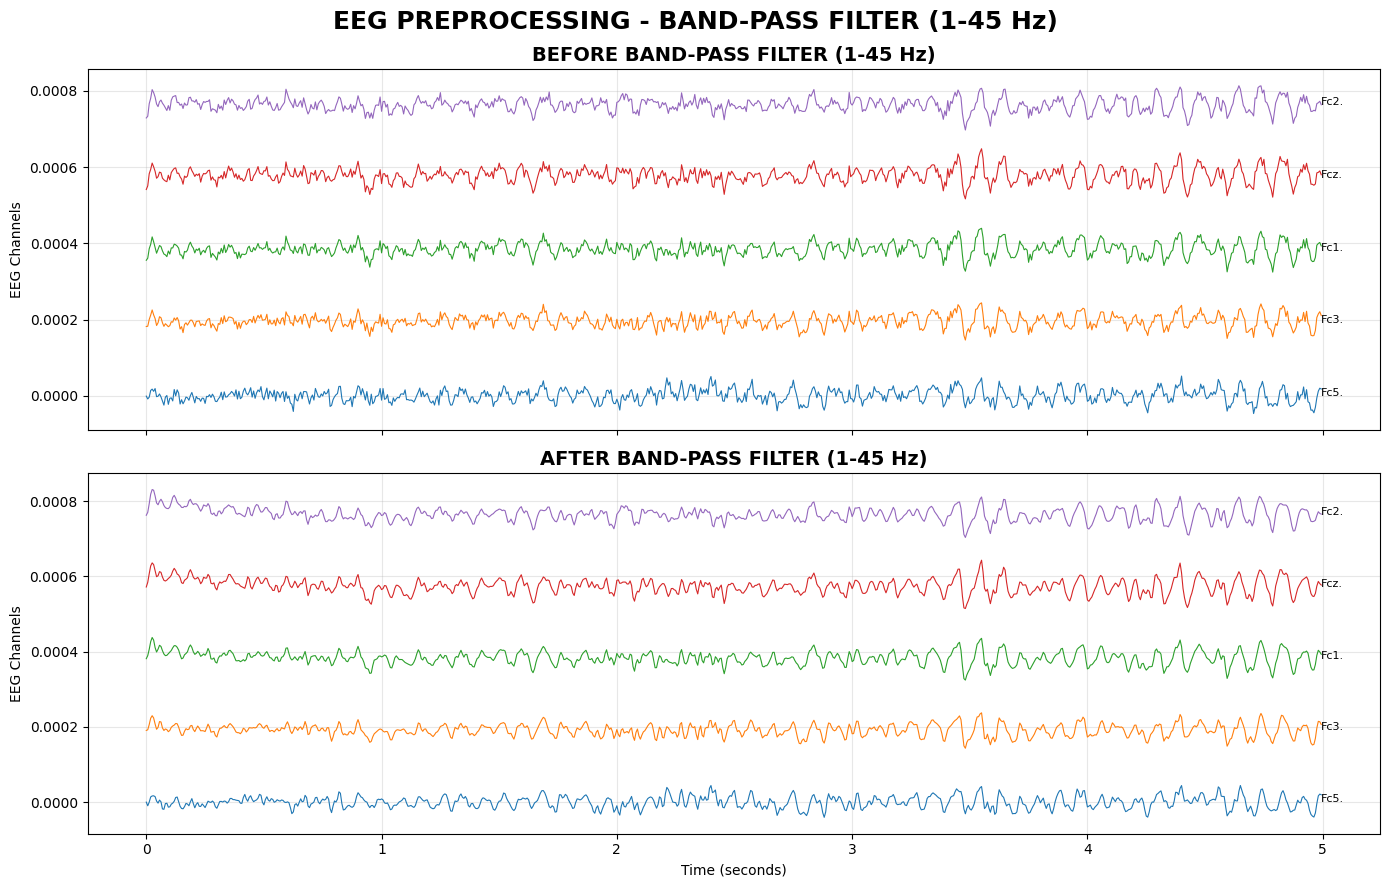

Saved: /content/eeg_graphs/02_bandpass_filter.png

STEP 4 - NOTCH FILTER (50 Hz)


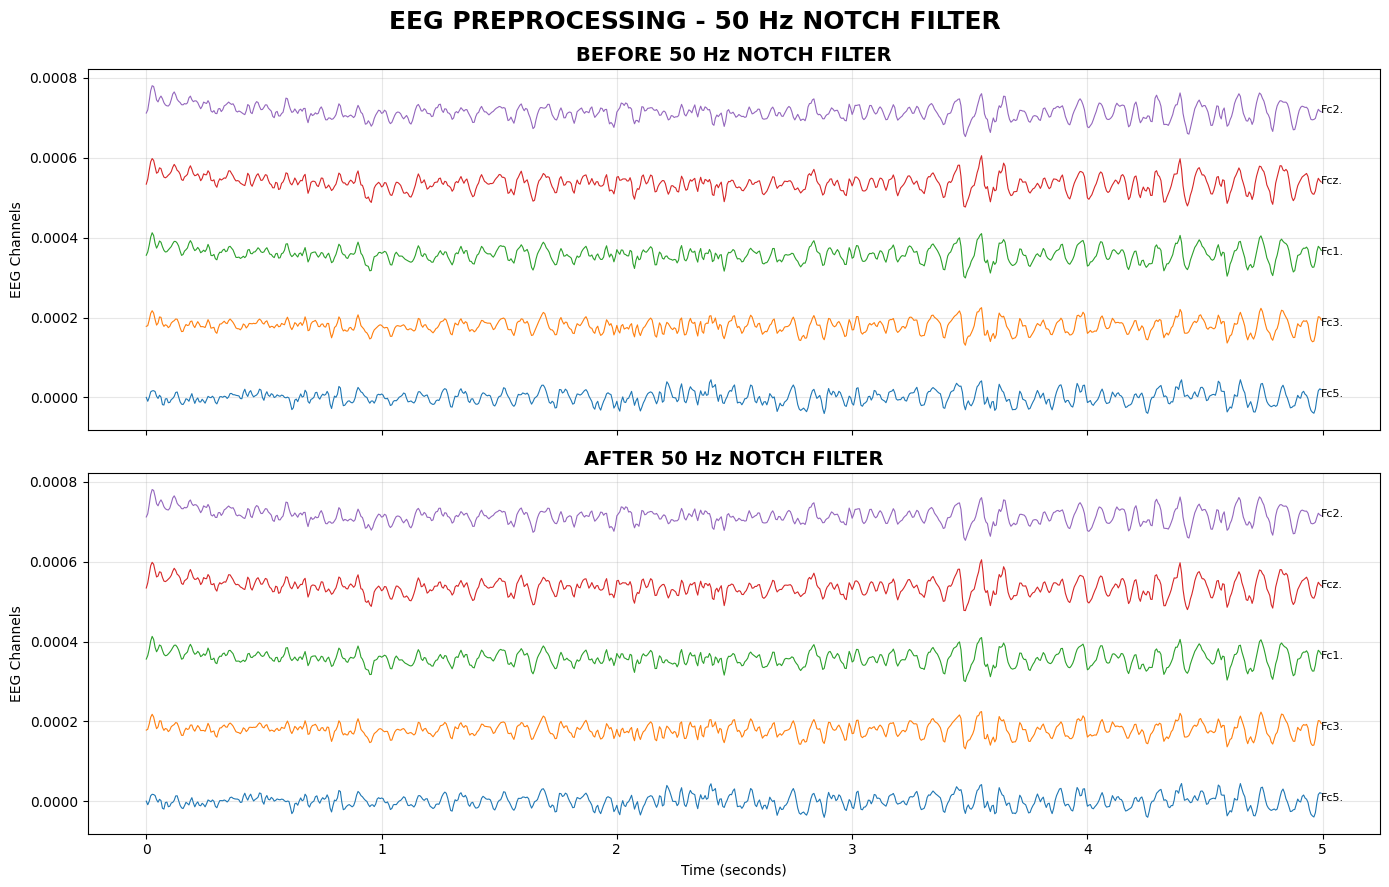

Saved: /content/eeg_graphs/03_notch_filter.png

STEP 5 - ICA ARTIFACT REMOVAL
Running ICA...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 1.7s.
ICA fitting completed.
Detecting possible eye-blink artifacts...
Using EOG channel: Fp1.
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1600 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-c

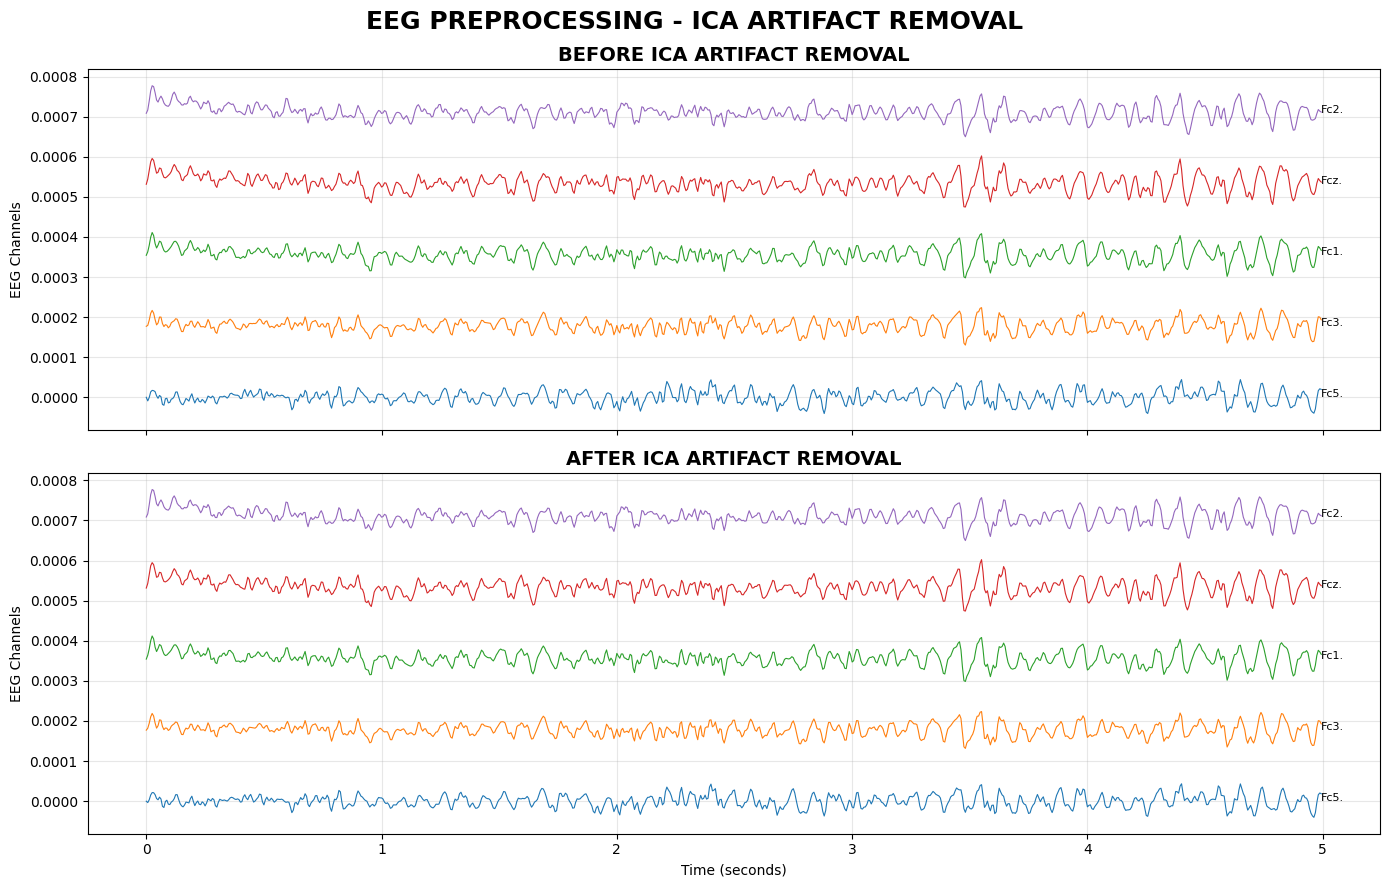

Saved: /content/eeg_graphs/04_ica_artifact_removal.png

STEP 6 - EPOCHING
Epoching completed.
Number of epochs: 30
Epoch duration: 2 seconds
Samples per epoch: 320

STEP 7 - NORMALIZATION
Original epoch data shape: (30, 64, 320)

BEFORE NORMALIZATION
Mean: 2.5543337315637494e-23
Standard deviation: 1.9279784238371633e-05

AFTER NORMALIZATION
Mean: 2.023844055306275e-19
Standard deviation: 0.9999938003784337


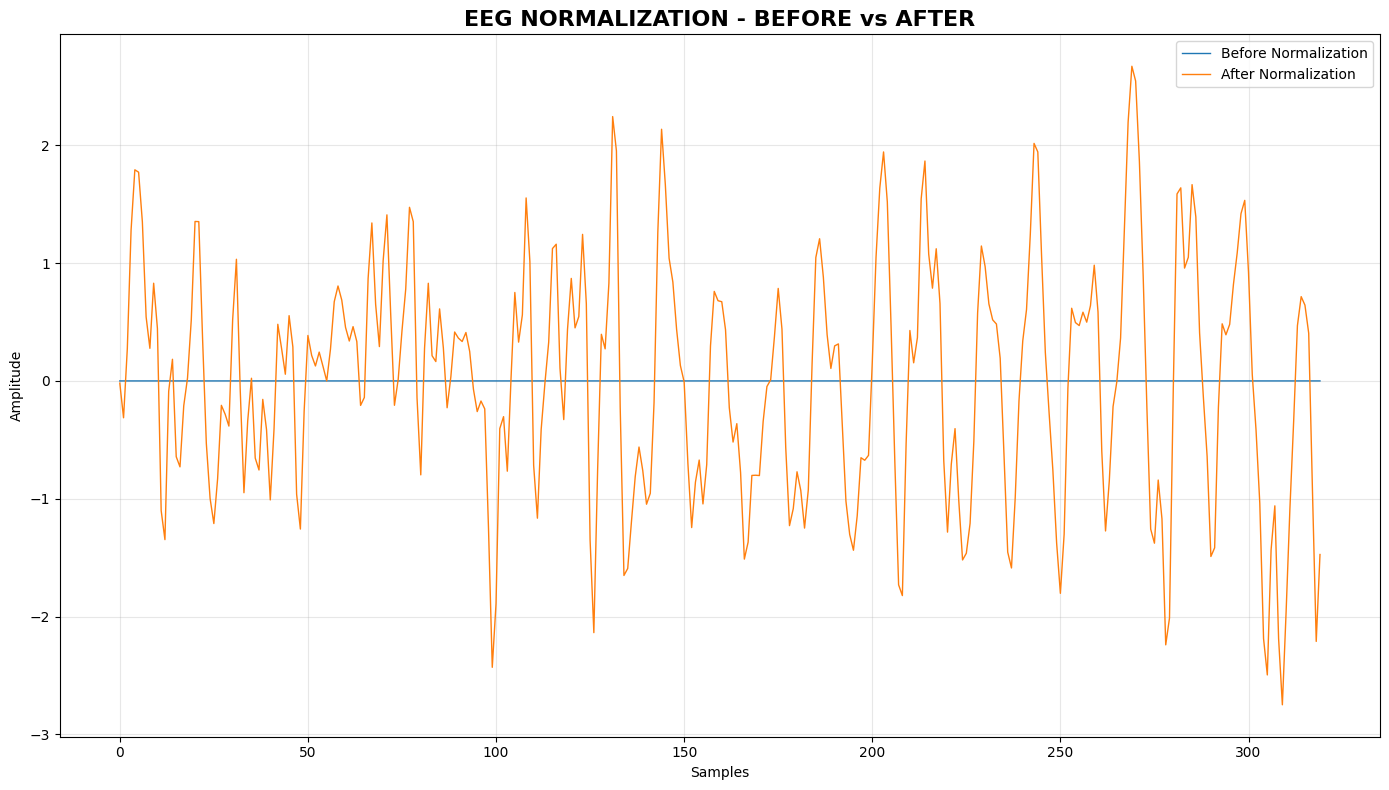

Saved: /content/eeg_graphs/05_normalization_before_after.png

STEP 8 - FINAL PREPROCESSED EEG
Final EEG created successfully.

FINAL EEG INFORMATION
---------------------
Number of epochs: 30
Number of channels: 64
Samples per epoch: 320
Final data shape: (30, 64, 320)


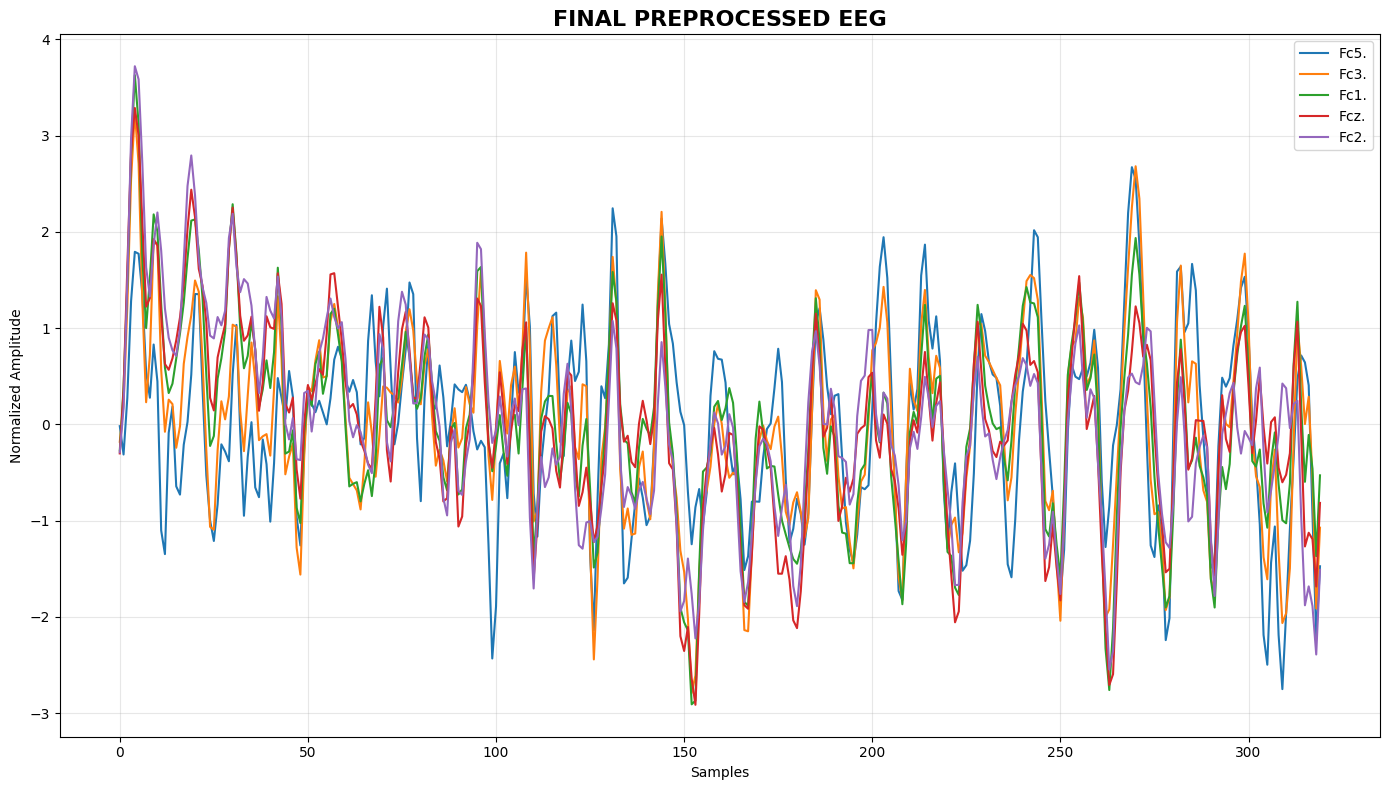


EEG PREPROCESSING COMPLETED SUCCESSFULLY

Processing performed:

1. Original EEG
2. Average Reference
3. Band-pass Filter: 1-45 Hz
4. Notch Filter: 50 Hz
5. ICA Artifact Removal
6. Epoching: 2 seconds
7. Z-score Normalization
8. Final Preprocessed EEG

FINAL DATA SHAPE: (30, 64, 320)

GRAPH FILES SAVED IN:
/content/eeg_graphs/

01_average_reference.png
02_bandpass_filter.png
03_notch_filter.png
04_ica_artifact_removal.png
05_normalization_before_after.png
06_final_preprocessed_eeg.png



In [5]:
# ============================================================
# COMPLETE EEG PREPROCESSING PIPELINE
# BEFORE & AFTER GRAPHS SAVED AS ONE IMAGE
# ============================================================

# Install MNE
!pip install -q mne

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import mne
import numpy as np
import matplotlib.pyplot as plt
import os

from mne.preprocessing import ICA


# ============================================================
# SETTINGS
# ============================================================

file_path = "/content/S002R02.edf"

# Folder to save graphs
os.makedirs("/content/eeg_graphs", exist_ok=True)


# ============================================================
# STEP 1: LOAD EEG
# ============================================================

if not os.path.exists(file_path):
    print("ERROR: File not found!")
    print("Files available:")
    print(os.listdir("/content"))
    raise FileNotFoundError(file_path)

raw = mne.io.read_raw_edf(
    file_path,
    preload=True,
    verbose=False
)

# Keep only EEG channels
raw.pick("eeg")

print("=" * 60)
print("EEG PREPROCESSING STARTED")
print("=" * 60)

print("\nORIGINAL EEG")
print("Number of channels:", len(raw.ch_names))
print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Duration:", raw.times[-1], "seconds")


# Save original copy
raw_original = raw.copy()


# ============================================================
# FUNCTION TO CREATE BEFORE/AFTER GRAPH
# ============================================================

def plot_before_after(
    before_raw,
    after_raw,
    title,
    filename,
    n_channels=5,
    duration=5
):
    """
    Creates ONE image containing Before and After graphs.
    """

    before_data = before_raw.get_data(
        start=0,
        stop=min(
            int(duration * before_raw.info["sfreq"]),
            before_raw.n_times
        )
    )

    after_data = after_raw.get_data(
        start=0,
        stop=min(
            int(duration * after_raw.info["sfreq"]),
            after_raw.n_times
        )
    )

    sfreq = before_raw.info["sfreq"]

    samples = min(
        before_data.shape[1],
        after_data.shape[1]
    )

    time = np.arange(samples) / sfreq

    n_channels = min(
        n_channels,
        before_data.shape[0],
        after_data.shape[0]
    )

    # Calculate scaling
    scale = np.max(
        np.abs(
            np.concatenate(
                [
                    before_data[:n_channels, :samples],
                    after_data[:n_channels, :samples]
                ],
                axis=1
            )
        )
    )

    if scale == 0:
        scale = 1

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 9),
        sharex=True
    )

    # --------------------------------------------------------
    # BEFORE
    # --------------------------------------------------------

    for i in range(n_channels):

        offset = i * scale * 2.5

        axes[0].plot(
            time,
            before_data[i, :samples] + offset,
            linewidth=0.8
        )

        axes[0].text(
            time[-1],
            offset,
            before_raw.ch_names[i],
            fontsize=8
        )

    axes[0].set_title(
        "BEFORE " + title,
        fontsize=14,
        fontweight="bold"
    )

    axes[0].set_ylabel("EEG Channels")
    axes[0].grid(True, alpha=0.3)


    # --------------------------------------------------------
    # AFTER
    # --------------------------------------------------------

    for i in range(n_channels):

        offset = i * scale * 2.5

        axes[1].plot(
            time,
            after_data[i, :samples] + offset,
            linewidth=0.8
        )

        axes[1].text(
            time[-1],
            offset,
            after_raw.ch_names[i],
            fontsize=8
        )

    axes[1].set_title(
        "AFTER " + title,
        fontsize=14,
        fontweight="bold"
    )

    axes[1].set_xlabel("Time (seconds)")
    axes[1].set_ylabel("EEG Channels")
    axes[1].grid(True, alpha=0.3)


    # --------------------------------------------------------
    # MAIN TITLE
    # --------------------------------------------------------

    fig.suptitle(
        "EEG PREPROCESSING - " + title,
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()

    # Save ONE image
    save_path = "/content/eeg_graphs/" + filename

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print("Saved:", save_path)


# ============================================================
# STEP 2: AVERAGE REFERENCE
# ============================================================

print("\n" + "=" * 60)
print("STEP 2 - AVERAGE REFERENCE")
print("=" * 60)

raw_before_reference = raw.copy()

# Apply average reference
raw.set_eeg_reference(
    "average",
    projection=False,
    verbose=False
)

raw_after_reference = raw.copy()

plot_before_after(
    raw_before_reference,
    raw_after_reference,
    "AVERAGE REFERENCE",
    "01_average_reference.png",
    n_channels=5,
    duration=5
)


# ============================================================
# STEP 3: BAND-PASS FILTER
# ============================================================

print("\n" + "=" * 60)
print("STEP 3 - BAND-PASS FILTER (1-45 Hz)")
print("=" * 60)

raw_before_bandpass = raw.copy()

# Apply 1-45 Hz filter
raw.filter(
    l_freq=1,
    h_freq=45,
    verbose=False
)

raw_after_bandpass = raw.copy()

plot_before_after(
    raw_before_bandpass,
    raw_after_bandpass,
    "BAND-PASS FILTER (1-45 Hz)",
    "02_bandpass_filter.png",
    n_channels=5,
    duration=5
)


# ============================================================
# STEP 4: NOTCH FILTER
# ============================================================

print("\n" + "=" * 60)
print("STEP 4 - NOTCH FILTER (50 Hz)")
print("=" * 60)

raw_before_notch = raw.copy()

# Apply 50 Hz notch filter
raw.notch_filter(
    freqs=50,
    verbose=False
)

raw_after_notch = raw.copy()

plot_before_after(
    raw_before_notch,
    raw_after_notch,
    "50 Hz NOTCH FILTER",
    "03_notch_filter.png",
    n_channels=5,
    duration=5
)


# ============================================================
# STEP 5: ICA ARTIFACT REMOVAL
# ============================================================

print("\n" + "=" * 60)
print("STEP 5 - ICA ARTIFACT REMOVAL")
print("=" * 60)

print("Running ICA...")

# Use available channels if fewer than 20
n_components = min(
    20,
    len(raw.ch_names)
)

ica = ICA(
    n_components=n_components,
    random_state=97,
    max_iter="auto"
)

ica.fit(raw)

print("ICA fitting completed.")


# ------------------------------------------------------------
# Detect EOG artifacts
# ------------------------------------------------------------

print("Detecting possible eye-blink artifacts...")

try:

    eog_indices, eog_scores = ica.find_bads_eog(
        raw,
        ch_name="Fp1."
    )

    print(
        "Possible eye-artifact components:",
        eog_indices
    )

except Exception as e:

    print(
        "Automatic EOG detection could not be completed."
    )

    print("Reason:", e)

    eog_indices = []


# ------------------------------------------------------------
# BEFORE ICA
# ------------------------------------------------------------

raw_before_ica = raw.copy()


# ------------------------------------------------------------
# Remove ICA components
# ------------------------------------------------------------

ica.exclude = eog_indices

print(
    "ICA components removed:",
    ica.exclude
)

raw_clean = raw.copy()

ica.apply(
    raw_clean,
    verbose=False
)


# ------------------------------------------------------------
# AFTER ICA
# ------------------------------------------------------------

raw_after_ica = raw_clean.copy()


plot_before_after(
    raw_before_ica,
    raw_after_ica,
    "ICA ARTIFACT REMOVAL",
    "04_ica_artifact_removal.png",
    n_channels=5,
    duration=5
)


# ============================================================
# STEP 6: EPOCHING
# ============================================================

print("\n" + "=" * 60)
print("STEP 6 - EPOCHING")
print("=" * 60)

# Create 2-second epochs
epochs = mne.make_fixed_length_epochs(
    raw_clean,
    duration=2.0,
    preload=True,
    verbose=False
)

print("Epoching completed.")
print("Number of epochs:", len(epochs))
print("Epoch duration: 2 seconds")
print(
    "Samples per epoch:",
    int(2 * raw.info["sfreq"])
)


# ============================================================
# STEP 7: NORMALIZATION
# ============================================================

print("\n" + "=" * 60)
print("STEP 7 - NORMALIZATION")
print("=" * 60)

# Get EEG data
data = epochs.get_data()

print(
    "Original epoch data shape:",
    data.shape
)


# ------------------------------------------------------------
# BEFORE NORMALIZATION
# ------------------------------------------------------------

before_mean = data.mean()
before_std = data.std()

print("\nBEFORE NORMALIZATION")
print("Mean:", before_mean)
print("Standard deviation:", before_std)


# ------------------------------------------------------------
# Z-SCORE NORMALIZATION
# ------------------------------------------------------------

mean = data.mean(
    axis=2,
    keepdims=True
)

std = data.std(
    axis=2,
    keepdims=True
)

data_normalized = (
    data - mean
) / (
    std + 1e-10
)


# ------------------------------------------------------------
# AFTER NORMALIZATION
# ------------------------------------------------------------

after_mean = data_normalized.mean()
after_std = data_normalized.std()

print("\nAFTER NORMALIZATION")
print("Mean:", after_mean)
print("Standard deviation:", after_std)


# ============================================================
# NORMALIZATION BEFORE/AFTER GRAPH
# ============================================================

plt.figure(figsize=(14, 8))

plt.plot(
    data[0, 0, :],
    label="Before Normalization",
    linewidth=1
)

plt.plot(
    data_normalized[0, 0, :],
    label="After Normalization",
    linewidth=1
)

plt.title(
    "EEG NORMALIZATION - BEFORE vs AFTER",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/eeg_graphs/05_normalization_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "Saved: /content/eeg_graphs/05_normalization_before_after.png"
)


# ============================================================
# STEP 8: CREATE FINAL EEG
# ============================================================

print("\n" + "=" * 60)
print("STEP 8 - FINAL PREPROCESSED EEG")
print("=" * 60)

epochs_normalized = mne.EpochsArray(
    data_normalized,
    epochs.info.copy(),
    verbose=False
)

print("Final EEG created successfully.")


# ============================================================
# FINAL INFORMATION
# ============================================================

print("\nFINAL EEG INFORMATION")
print("---------------------")

print(
    "Number of epochs:",
    len(epochs_normalized)
)

print(
    "Number of channels:",
    len(epochs_normalized.ch_names)
)

print(
    "Samples per epoch:",
    data_normalized.shape[2]
)

print(
    "Final data shape:",
    data_normalized.shape
)


# ============================================================
# FINAL GRAPH
# ============================================================

final_data = data_normalized[
    0,
    :min(5, data_normalized.shape[1]),
    :
]

plt.figure(figsize=(14, 8))

for i in range(final_data.shape[0]):

    plt.plot(
        final_data[i],
        label=epochs_normalized.ch_names[i]
    )

plt.title(
    "FINAL PREPROCESSED EEG",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Samples")
plt.ylabel("Normalized Amplitude")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/eeg_graphs/06_final_preprocessed_eeg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 60)
print("EEG PREPROCESSING COMPLETED SUCCESSFULLY")
print("=" * 60)

print("""
Processing performed:

1. Original EEG
2. Average Reference
3. Band-pass Filter: 1-45 Hz
4. Notch Filter: 50 Hz
5. ICA Artifact Removal
6. Epoching: 2 seconds
7. Z-score Normalization
8. Final Preprocessed EEG
""")

print(
    "FINAL DATA SHAPE:",
    data_normalized.shape
)

print("\nGRAPH FILES SAVED IN:")
print("/content/eeg_graphs/")

print("""
01_average_reference.png
02_bandpass_filter.png
03_notch_filter.png
04_ica_artifact_removal.png
05_normalization_before_after.png
06_final_preprocessed_eeg.png
""")